In [1]:
import jax
import jax.numpy as jnp
from jax import grad, random
import matplotlib.pyplot as plt
import numpy as np

In [2]:
# Mixture of two Gaussians: N(-2, 0.5^2) and N(2, 0.5^2)
sigma = 1
mu1, mu2 = -2.0, 2.0
mix_weight = 0.5

def target_pdf(x):
    norm_const = 1/(jnp.sqrt(2*jnp.pi)*sigma)
    comp1 = norm_const * jnp.exp(-0.5 * ((x - mu1) / sigma)**2)
    comp2 = norm_const * jnp.exp(-0.5 * ((x - mu2) / sigma)**2)
    return mix_weight * comp1 + (1 - mix_weight) * comp2

def sample_target(key, num_samples):    
    # Sample from the mixture by first choosing a component then sampling from it
    key, subkey = random.split(key)
    component = random.bernoulli(subkey, p=mix_weight, shape=(num_samples,))
    key, subkey1, subkey2 = random.split(key, 3)
    samples1 = random.normal(subkey1, shape=(num_samples,)) * sigma + mu1
    samples2 = random.normal(subkey2, shape=(num_samples,)) * sigma + mu2
    return jnp.where(component, samples2, samples1)

CUDA backend failed to initialize: Unable to use CUDA because of the following issues with CUDA components:
Outdated cuDNN installation found.
Version JAX was built against: 8907
Minimum supported: 9100
Installed version: 8907
The local installation version must be no lower than 9100..(Set TF_CPP_MIN_LOG_LEVEL=0 and rerun for more info.)


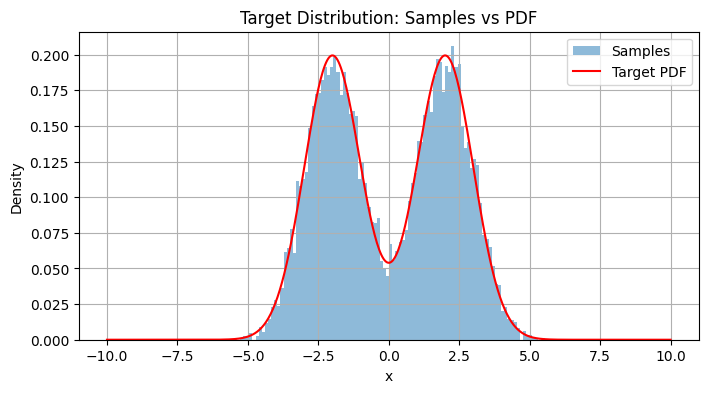

In [3]:
# Plot the target distribution
x_vals = np.linspace(-10, 10, 500)
target_vals = np.array(target_pdf(x_vals))

# Optional: Also show samples from the distribution
key = random.PRNGKey(0)
samples = sample_target(key, 10000)
plt.figure(figsize=(8, 4))
plt.hist(samples, bins=100, density=True, alpha=0.5, label='Samples')
plt.plot(x_vals, target_vals, 'r-', label='Target PDF')
plt.xlabel('x')
plt.ylabel('Density')
plt.title('Target Distribution: Samples vs PDF')
plt.legend()
plt.grid(True)
plt.show()

In [4]:
# -----------------------------
# Define polynomial score model
# -----------------------------
def score_function(theta, x):
    """
    Compute the score s_theta(x) = sum_{i=1}^{order} theta[i-1] * x^i.
    x can be a batch (1D array).
    """
    orders = jnp.arange(1, theta.shape[0] + 1)  # [1, 2, 3, ...]
    # x[:, None] ** orders[None, :] creates a (batch, order) array of x^i.
    poly = x[:, None] ** orders[None, :]
    return jnp.sum(theta * poly, axis=1)

def score_function_derivative(theta, x):
    """
    Compute d/dx s_theta(x) = sum_{i=1}^{order} i * theta[i-1] * x^(i-1).
    """
    orders = jnp.arange(1, theta.shape[0] + 1)
    poly_deriv = x[:, None] ** (orders[None, :] - 1)
    return jnp.sum(orders * theta * poly_deriv, axis=1)

# ----------------------
# Define score matching loss
# ----------------------
def loss_fn(theta, x):
    """
    Score matching objective in 1D:
      L(θ) = E[0.5 * s_θ(x)^2 + d/dx s_θ(x)]
    where the expectation is taken over samples from the target distribution.
    """
    s = score_function(theta, x)
    ds = score_function_derivative(theta, x)
    return jnp.mean(0.5 * s**2 + ds)



In [5]:
# ---------------------
# Train score function via score matching
# ---------------------
learning_rate = 1e-5
num_iters = 1000
batch_size = 10000
order = 4  # we use a cubic polynomial: s(x) = a*x + b*x^2 + c*x^3

# Initialize tracking arrays
theta_history = []
loss_history = []

key = random.PRNGKey(0)
theta = jnp.zeros(order)  # initialize parameters (a, b, c) at zero

grad_loss_fn = grad(loss_fn)

for i in range(num_iters):
    key, subkey = random.split(key)
    x_batch = sample_target(subkey, batch_size)
    grads = grad_loss_fn(theta, x_batch)
    theta = theta - learning_rate * grads
    
    # Track parameters and loss
    current_loss = loss_fn(theta, x_batch)
    theta_history.append(np.array(theta))
    loss_history.append(float(current_loss))
    
    if i % 100 == 0:
        print(f"Iteration {i}, loss: {current_loss}")

print("Learned theta:", theta)


Iteration 0, loss: -0.002231497084721923
Iteration 100, loss: -0.14363007247447968
Iteration 200, loss: -0.19460472464561462
Iteration 300, loss: -0.21197509765625
Iteration 400, loss: -0.21798543632030487
Iteration 500, loss: -0.2186461091041565
Iteration 600, loss: -0.22402577102184296
Iteration 700, loss: -0.22156119346618652
Iteration 800, loss: -0.22273890674114227
Iteration 900, loss: -0.23337845504283905
Learned theta: [ 3.6255203e-04  2.5747722e-06 -2.9831719e-02  7.9936675e-05]


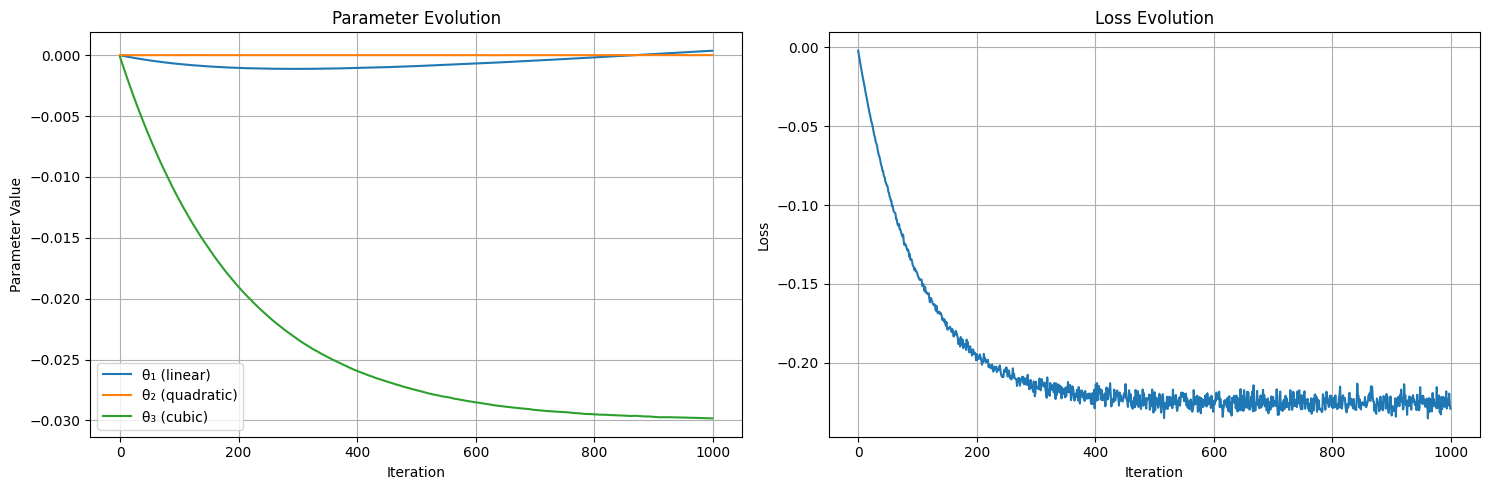

In [6]:

# Convert histories to numpy arrays for plotting
theta_history = jnp.array(theta_history)
loss_history = jnp.array(loss_history)

# Create figure with two subplots
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 5))

# Plot parameter evolution
ax1.plot(theta_history[:, 0], label='θ₁ (linear)')
ax1.plot(theta_history[:, 1], label='θ₂ (quadratic)')
ax1.plot(theta_history[:, 2], label='θ₃ (cubic)')
ax1.set_xlabel('Iteration')
ax1.set_ylabel('Parameter Value')
ax1.set_title('Parameter Evolution')
ax1.legend()
ax1.grid(True)

# Plot loss evolution
ax2.plot(loss_history)
ax2.set_xlabel('Iteration')
ax2.set_ylabel('Loss')
ax2.set_title('Loss Evolution')
ax2.grid(True)
# ax2.set_yscale('log')  # Use log scale for loss

plt.tight_layout()
plt.show()

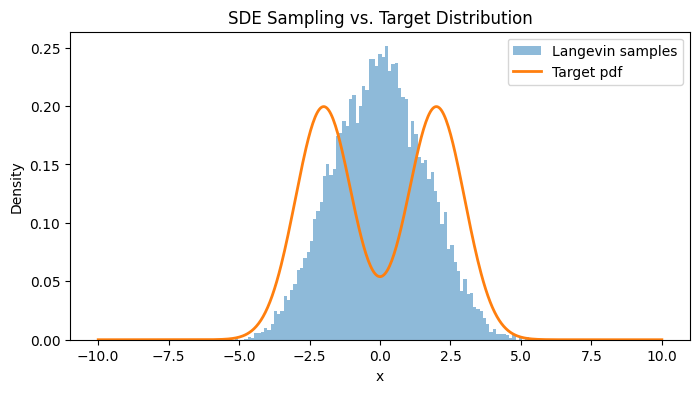

In [7]:
# -------------------------------
# Run Langevin dynamics (SDE) with the learned score
# -------------------------------
# Overdamped Langevin dynamics:
#   x_{t+1} = x_t + 0.5 * dt * s_theta(x_t) + sqrt(dt)*N(0,1)
num_steps = 1000
dt = 1e-3
num_samples = 10000

key, subkey = random.split(key)
x = random.normal(subkey, shape=(num_samples,))  # initial samples (e.g. standard normal)

for i in range(num_steps):
    key, subkey = random.split(key)
    noise = random.normal(subkey, shape=(num_samples,))
    s_x = score_function(theta, x)
    x = x + 0.5 * dt * s_x + jnp.sqrt(2*dt) * noise

# -------------------------------
# Compare generated samples to target distribution
# -------------------------------
# Convert x to a NumPy array for plotting.
x_samples = np.array(x)
x_vals = np.linspace(-10, 10, 500)
target_vals = np.array(target_pdf(x_vals))

plt.figure(figsize=(8, 4))
plt.hist(x_samples, bins=100, density=True, alpha=0.5, label="Langevin samples")
plt.plot(x_vals, target_vals, label="Target pdf", lw=2)
plt.xlabel("x")
plt.ylabel("Density")
plt.legend()
plt.title("SDE Sampling vs. Target Distribution")
plt.show()
